###### Case Study 1:
Dataset Description: The file consists of start-ups investment details.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
df = pd.read_csv('investments.csv')
df.head(5)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant
0,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York,1,2012.0,0,0
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2,NaN,0,0
2,Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,Tallinn,1,2012.0,0,0
3,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,London,1,2011.0,0,0
4,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,Fort Worth,2,2014.0,0,0


In [3]:
df.shape

(49438, 14)

In [4]:
# 2.	List out all column names.
df.columns
# list(df)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_year', 'debt_financing', 'grant'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49438 entries, 0 to 49437
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               49437 non-null  object 
 1   homepage_url       45989 non-null  object 
 2   category_list      45477 non-null  object 
 3   market             45470 non-null  object 
 4   funding_total_usd  49438 non-null  object 
 5   status             48124 non-null  object 
 6   country_code       44165 non-null  object 
 7   state_code         30161 non-null  object 
 8   region             44165 non-null  object 
 9   city               43322 non-null  object 
 10  funding_rounds     49438 non-null  int64  
 11  founded_year       38482 non-null  float64
 12  debt_financing     49438 non-null  int64  
 13  grant              49438 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 5.3+ MB


In [6]:
# 3.	Create a dataframe with numerical columns.
df2 = df.select_dtypes(['number'])
df2.head()

,funding_rounds,founded_year,debt_financing,grant
0,1,2012.0,0,0
1,2,NaN,0,0
2,1,2012.0,0,0
3,1,2011.0,0,0
4,2,2014.0,0,0


In [7]:
# 4.	Create a dataframe with categorical columns.
df2 = df.select_dtypes(np.object)
df2.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city
0,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles
2,Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,Tallinn
3,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,London
4,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,Fort Worth


In [8]:
# 5.	Get a summary on the data and draw inferences if any.
df.describe()
#### data validate + stastical summary + draw inferences based on observations (facts)

,funding_rounds,founded_year,debt_financing,grant
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,1.888157e+06,1.628453e+05
std,1.294213,7.579203,1.382046e+08,5.612088e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,3.007950e+10,7.505000e+08


In [9]:
# 6.	Display duplicate rows.
df.duplicated().sum()   ### row -level duplicates

0

In [10]:
#### 
df.duplicated(['name','category_list','market']).sum() # there are 3 records which have duplicate copies at ['name','category_list','market'] level

3

In [11]:
df[df.duplicated(['name','category_list','market'])] # these 3 records have duplicate copies at ['name','category_list','market'] level

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant
4150,AYOXXA Biosystems,http://www.ayoxxa.com/,|Biotechnology|,Biotechnology,"1,40,81,347",operating,DEU,NaN,Cologne,Köln,1,2010.0,0,0
24028,Lightex Ltd.,NaN,NaN,NaN,"5,00,000",operating,NaN,NaN,NaN,NaN,1,NaN,0,0
36084,Roadmap,NaN,NaN,NaN,-,operating,USA,NC,Charlotte,Charlotte,1,2011.0,0,0


In [12]:
#### list out duplicate copies of the record in index 36084
f = (df.name == 'Roadmap') & (df.category_list.isna()) & (df.market.isna())
df[f]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant
36083,Roadmap,http://www.roadmapsystems.co.uk/,NaN,NaN,-,operating,GBR,NaN,London,Cambridge,1,NaN,0,0
36084,Roadmap,NaN,NaN,NaN,-,operating,USA,NC,Charlotte,Charlotte,1,2011.0,0,0


In [13]:
#### list out duplicate copies of the record in index 4150
f = (df.name == 'AYOXXA Biosystems') & (df.category_list == '|Biotechnology|' ) & (df.market == 'Biotechnology')
df[f]


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant
4149,AYOXXA Biosystems,http://ayoxxa.com,|Biotechnology|,Biotechnology,"1,21,45,503",operating,DEU,NaN,Cologne,Cologne,1,2010.0,0,0
4150,AYOXXA Biosystems,http://www.ayoxxa.com/,|Biotechnology|,Biotechnology,"1,40,81,347",operating,DEU,NaN,Cologne,Köln,1,2010.0,0,0


In [14]:
# df.drop_duplicates().shape
df.drop_duplicates(subset = ['name','category_list','market'], keep = False).shape

(49432, 14)

In [15]:
df.shape

(49438, 14)

In [16]:
# 7.	For each column find out the percentage of missing values.
count = df.isnull().sum() ## count of the missing values
percentage = df.isnull().sum()/len(df) * 100  ## %age of missing values
pd.concat([count, percentage], axis = 1, keys = ['count', '%age']).sort_values('%age', ascending = False)

,count,%age
state_code,19277,38.992273
founded_year,10956,22.161091
city,6116,12.371051
country_code,5273,10.665885
region,5273,10.665885
market,3968,8.026215
category_list,3961,8.012056
homepage_url,3449,6.976415
status,1314,2.657875
name,1,0.002023


In [17]:
# 8.	Find count of ‘name’ in each ‘country_code’.
df.groupby(['country_code'])['name'].count()

country_code
ALB        1
ARE       66
ARG      149
ARM        2
AUS      314
       ...  
USA    28793
UZB        1
VNM       21
ZAF       52
ZWE        1
Name: name, Length: 115, dtype: int64

In [18]:
# df.country_code.value_counts()

In [19]:
# 9.	What is the percentage of the companies which have status ‘acquired’ or ‘operating’?
df[df.status.isin(['acquired','operating'])].shape[0]/df.shape[0]*100

92.07694486022898

In [20]:
# 10.	What is the percentage of the companies which have status ‘acquired’ and operating?

In [21]:
# 11.	Filter records having missing values in column ‘year_founded’.
df[df.founded_year.isnull()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2,NaN,0,0
6,.Fox Networks,http://www.dotfox.com,|Advertising|,Advertising,"49,12,393",closed,ARG,NaN,Buenos Aires,Buenos Aires,1,NaN,0,0
9,01Games Technology,http://www.01games.hk/,|Games|,Games,"41,250",operating,HKG,NaN,Hong Kong,Hong Kong,1,NaN,0,0
11,1-4 All,NaN,|Entertainment|Games|Software|,Software,-,operating,USA,NC,NC - Other,Connellys Springs,1,NaN,0,0
19,1000jobboersen.de,http://www.1000jobboersen.de,|Curated Web|,Curated Web,-,operating,DEU,NaN,Berlin,Berlin,1,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49412,Zygo Corporation,http://www.zygo.com,|Manufacturing|,Manufacturing,"90,00,000",NaN,USA,CT,CT - Other,Middlefield,1,NaN,0,0
49422,"Zymr, Inc.",http://www.zymr.com,|Open Source|Network Security|Networking|Virtu...,Testing,-,operating,USA,CA,SF Bay Area,Santa Clara,1,NaN,0,0
49431,Zyrra,http://www.zyrra.com,|E-Commerce|,E-Commerce,"15,10,500",operating,USA,MA,Boston,Cambridge,4,NaN,0,0
49434,ZZNode Science and Technology,http://www.zznode.com,|Enterprise Software|,Enterprise Software,"15,87,301",operating,CHN,NaN,Beijing,Beijing,1,NaN,0,0


In [22]:
# 12.	Create a column ‘category_list_count’ having count of category lists.
df['category_list_count'] = df.category_list.apply(lambda row : len(str(row).split('|')) - 2)
df.loc[:,['category_list','category_list_count']].head()

,category_list,category_list_count
0,|Entertainment|Politics|Social Media|News|,4
1,|Games|,1
2,|Publishing|Education|,2
3,|Electronics|Guides|Coffee|Restaurants|Music|i...,10
4,|Tourism|Entertainment|Games|,3


In [23]:
# 13.	Find average funding_total_usd for each country_code.
df.funding_total_usd = df.funding_total_usd.apply(lambda x : x.replace(',',''))
df.funding_total_usd = df.funding_total_usd.apply(lambda x : x.replace('-','0'))
df.funding_total_usd = df.funding_total_usd.astype(float)
df.groupby('country_code')['funding_total_usd'].mean()

country_code
ALB    0.000000e+00
ARE    9.832352e+06
ARG    1.787353e+06
ARM    1.340649e+07
AUS    8.276922e+06
           ...     
USA    1.612353e+07
UZB    9.000000e+04
VNM    1.023431e+07
ZAF    1.243687e+07
ZWE    1.000000e+07
Name: funding_total_usd, Length: 115, dtype: float64

In [24]:
# 14.	Find total funding_total_usd for each country_code.
df.groupby('country_code')['funding_total_usd'].sum()

country_code
ALB    0.000000e+00
ARE    6.489352e+08
ARG    2.663157e+08
ARM    2.681298e+07
AUS    2.598953e+09
           ...     
USA    4.642448e+11
UZB    9.000000e+04
VNM    2.149205e+08
ZAF    6.467170e+08
ZWE    1.000000e+07
Name: funding_total_usd, Length: 115, dtype: float64

In [25]:
# 15.	Find average funding_total_usd in each country_code and region.
df.groupby(['country_code','region'])[['funding_total_usd']].mean()

funding_total_usd
country_code region                         
ALB          Tirana             0.000000e+00
ARE          Abu Dhabi          1.562500e+07
             Dubai              9.651332e+06
ARG          ARG - Other        3.049519e+05
             Buenos Aires       1.760614e+06
...                                      ...
ZAF          Cape Town          1.559547e+07
             Durban             0.000000e+00
             Johannesburg       6.091429e+06
             ZAF - Other        0.000000e+00
ZWE          Harare             1.000000e+07

[1096 rows x 1 columns]

In [26]:
pd.pivot_table(data = df, values = 'funding_total_usd', index = ['country_code','region'], aggfunc='mean' )

funding_total_usd
country_code region                         
ALB          Tirana             0.000000e+00
ARE          Abu Dhabi          1.562500e+07
             Dubai              9.651332e+06
ARG          ARG - Other        3.049519e+05
             Buenos Aires       1.760614e+06
...                                      ...
ZAF          Cape Town          1.559547e+07
             Durban             0.000000e+00
             Johannesburg       6.091429e+06
             ZAF - Other        0.000000e+00
ZWE          Harare             1.000000e+07

[1096 rows x 1 columns]

In [27]:
# 16.	How many companies have got just 1 round of funding?
print(df[df.funding_rounds == 1]['name'].shape[0]) ### including duplicates
print(len(df[df.funding_rounds == 1]['name'].unique())) ### excluding duplicates
print(df[df.funding_rounds == 1]['name'].nunique()) ## excluding duplicates and nan
print(df[df.funding_rounds == 1]['name'].count()) ### including duplicates but excluding nan

32039
32006
32005
32038


In [28]:
# 17.	Perform mapping on status column; acquired -> A, operating -> O and closed -> C.
df.status.apply(lambda s: 'A' if s == 'acquired' else 'O' if s == 'operating' else 'C' if s=='closed' else 'NA').head()

0    A
1    O
2    O
3    O
4    O
Name: status, dtype: object

In [29]:
# 18.	How many companies have ‘debt_financing’ above zero?
print(df[df.debt_financing > 0]['name'].shape[0]) ### including duplicates
print(len(df[df.debt_financing > 0]['name'].unique())) ### excluding duplicates
print(df[df.debt_financing > 0]['name'].nunique()) ## excluding duplicates and nan
print(df[df.debt_financing > 0]['name'].count()) ### including duplicates but excluding nan

4225
4225
4225
4225


In [30]:
# 19.	Create a column ‘homepage’ to store company name from ‘homepage_url’: 
# For example: If url is http://www.waywire.com, name is waywire.
import re

df.homepage_url.apply(lambda url: re.sub(pattern = ('http://www.|.com|/|http:|.org'), repl = '', string = str(url), flags= re.I)).head()

0           waywire
1        enjoyandtv
2     rockyourpaper
3    InTouchNetwork
4               nan
Name: homepage_url, dtype: object

In [31]:
# 20.	Find the count of companies in each of the markets.
df.groupby('market')['name'].count()

market
3D               25
3D Printing       9
3D Technology     8
Accounting       18
Ad Targeting     13
                 ..
iOS              48
iPad             29
iPhone           69
iPod Touch        3
mHealth           8
Name: name, Length: 753, dtype: int64

In [32]:
# 21.	Find the count of companies in each of the markets and 
# store the new column ‘cnt_name’ in the original dataframe.
df['cnt_name_market'] = df.groupby('market')['name'].transform('count')
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant,category_list_count,cnt_name_market
0,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1,2012.0,0,0,4,378.0
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2,NaN,0,0,1,1182.0
2,Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,Tallinn,1,2012.0,0,0,2,69.0
3,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,London,1,2011.0,0,0,10,43.0
4,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,Fort Worth,2,2014.0,0,0,3,21.0


In [33]:
# 22.	Rename ' funding_total_usd ' to 'funding_total_usd'

In [34]:
# 23.	Fill missing values in column ‘city’ with ‘other_city’
# df.city.isnull().sum()
# df.city.tolist()
df.city.fillna('other_city', inplace = True)

In [35]:
# 24.	For each row in column ‘funding_total_usd’, calculate actual – average value for each group ‘city’
df.groupby('city')['funding_total_usd'].transform(lambda x: x - np.mean(x)).head()

0   -2.444616e+07
1   -7.234447e+06
2   -1.723232e+06
3   -6.784773e+06
4   -3.522942e+07
Name: funding_total_usd, dtype: float64

In [36]:
# 25.	Normalize ‘‘funding_total_usd’ at country level.
df.country_code.fillna('other_country', inplace = True)
df.groupby('country_code')['funding_total_usd'].transform(lambda x: x/np.max(x)).head()

0    0.000058
1    0.000133
2    0.002106
3    0.002381
4    0.000002
Name: funding_total_usd, dtype: float64

In [37]:
# 26.	What is the average ‘funding_total_usd’ for each city?
df.groupby('city')['funding_total_usd'].mean().head()

city
6 October City    1.450000e+05
A Coruña          1.236930e+06
Aachen            6.448845e+06
Aalborg           1.166667e+05
Aarhus            2.546595e+06
Name: funding_total_usd, dtype: float64

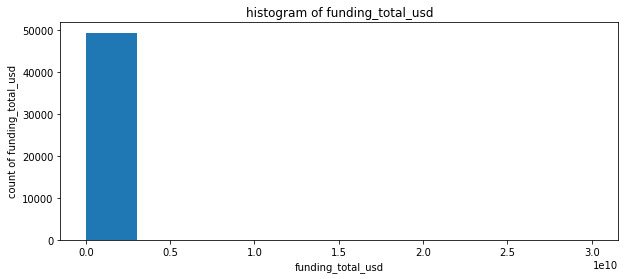

In [38]:
# 27.	Plot histogram/distribution of ‘funding_total_usd’ and provide insights if any.
plt.figure(figsize = (10,4))
plt.hist(df.funding_total_usd)
plt.xlabel('funding_total_usd')
plt.ylabel('count of funding_total_usd')
plt.title('histogram of funding_total_usd')
plt.show()

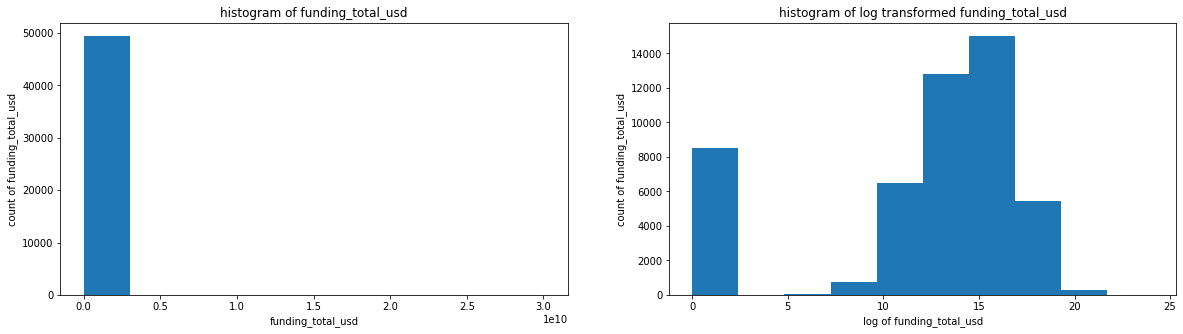

In [39]:
fig, ax = plt.subplots(1,2,figsize = (20,5))
ax[0].hist(df.funding_total_usd)
ax[0].set_xlabel('funding_total_usd')
ax[0].set_ylabel('count of funding_total_usd')
ax[0].set_title('histogram of funding_total_usd')

ax[1].hist(np.log1p(df.funding_total_usd))
ax[1].set_xlabel('log of funding_total_usd')
ax[1].set_ylabel('count of funding_total_usd')
ax[1].set_title('histogram of log transformed funding_total_usd')
plt.show()

In [40]:
# 28.	What is maximum ‘funding_total_usd’ for each market status?
df.groupby('status')['funding_total_usd'].max()

status
acquired     5.700000e+09
closed       1.567504e+09
operating    3.007950e+10
Name: funding_total_usd, dtype: float64

In [41]:
# 29.	How many years has it been since each company was founded?
from datetime import datetime
df['cmpany_age'] = datetime.today().year -  df.founded_year
df.head()
# 2021 - df.founded_year

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant,category_list_count,cnt_name_market,cmpany_age
0,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1,2012.0,0,0,4,378.0,9.0
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2,NaN,0,0,1,1182.0,NaN
2,Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,Tallinn,1,2012.0,0,0,2,69.0,9.0
3,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,London,1,2011.0,0,0,10,43.0,10.0
4,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,Fort Worth,2,2014.0,0,0,3,21.0,7.0


In [42]:
# df.groupby('market')[['grant']].max().reset_index().sort_values('grant', ascending = False)[0:10]

Text(0.5, 1.0, 'Top 10 markets with high grants')

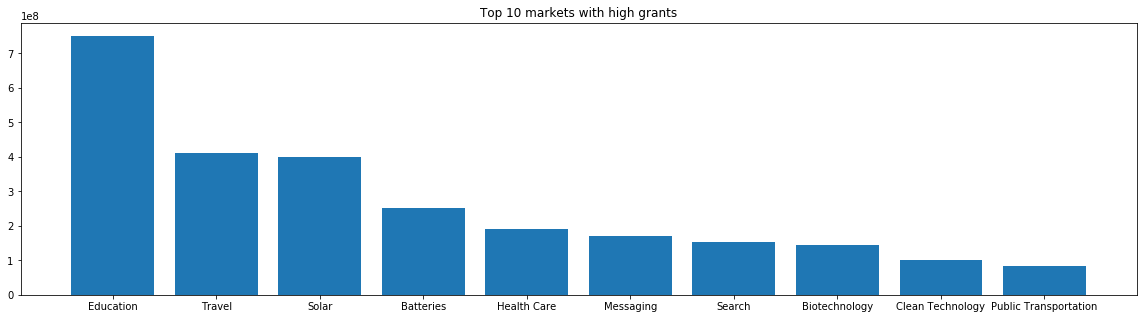

In [43]:
x = df.groupby('market')[['grant']].max().reset_index().sort_values('grant', ascending = False)[0:10]
plt.figure(figsize = (20,5))
plt.bar(x.market, x.grant)
# plt.xlabel()
plt.title('Top 10 markets with high grants')

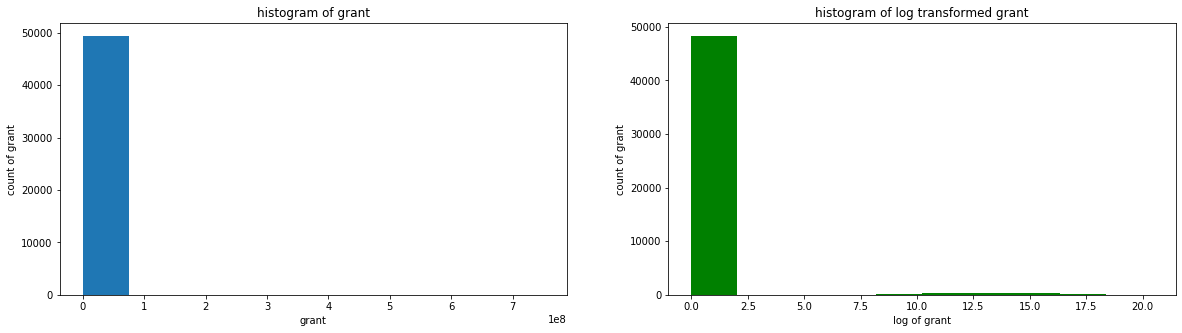

In [44]:
# 30.	Visualize ‘grant’ distribution.
fig, ax = plt.subplots(1,2,figsize = (20,5))
ax[0].hist(df.grant)
ax[0].set_xlabel('grant')
ax[0].set_ylabel('count of grant')
ax[0].set_title('histogram of grant')

ax[1].hist(np.log1p(df.grant), color = 'g')
ax[1].set_xlabel('log of grant')
ax[1].set_ylabel('count of grant')
ax[1].set_title('histogram of log transformed grant')
plt.show()

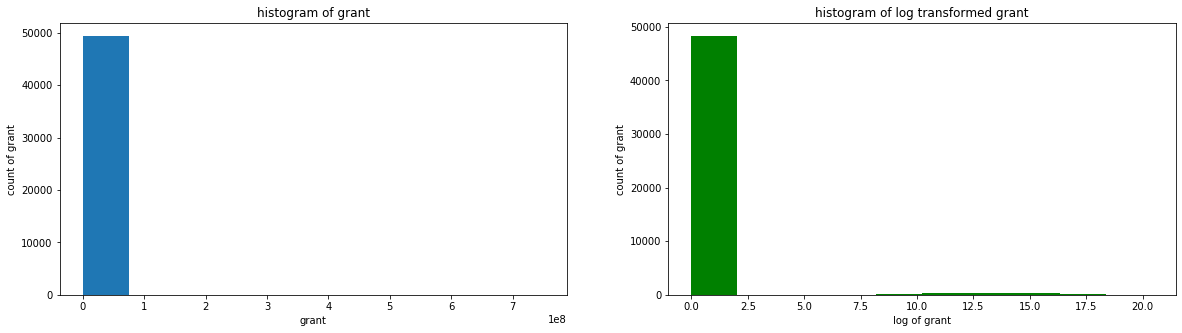

In [45]:
# 31.	Visualize ‘debt_financing’ distribution.
fig, ax = plt.subplots(1,2,figsize = (20,5))
ax[0].hist(df.grant)
ax[0].set_xlabel('grant')
ax[0].set_ylabel('count of grant')
ax[0].set_title('histogram of grant')

ax[1].hist(np.log1p(df.grant), color = 'g')
ax[1].set_xlabel('log of grant')
ax[1].set_ylabel('count of grant')
ax[1].set_title('histogram of log transformed grant')
plt.show()

In [46]:
# 32.	Display proportion of companies status.
df.groupby('status')[['name']].count()/len(df)*100

,name
status,
acquired,7.467940
closed,5.263158
operating,84.609005


In [47]:
# 33.	How many US states are available?
df[df.country_code == 'USA']['state_code'].nunique()

51

In [48]:
# 34.	create column ‘cmt_address’ by joining country code, state code, region and city.

df['cmt_address']  = df.country_code + '-' + df.state_code + '-' + df.region + '-'+ df.city
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_year,debt_financing,grant,category_list_count,cnt_name_market,cmpany_age,cmt_address
0,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1,2012.0,0,0,4,378.0,9.0,USA-NY-New York City-New York
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2,NaN,0,0,1,1182.0,NaN,USA-CA-Los Angeles-Los Angeles
2,Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,Tallinn,1,2012.0,0,0,2,69.0,9.0,NaN
3,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,London,1,2011.0,0,0,10,43.0,10.0,NaN
4,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,Fort Worth,2,2014.0,0,0,3,21.0,7.0,USA-TX-Dallas-Fort Worth


In [49]:
# 35.	select columns with underscore in their names.
df.filter(regex = '_').head()

,homepage_url,category_list,funding_total_usd,country_code,state_code,funding_rounds,founded_year,debt_financing,category_list_count,cnt_name_market,cmpany_age,cmt_address
0,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,1750000.0,USA,NY,1,2012.0,0,4,378.0,9.0,USA-NY-New York City-New York
1,http://enjoyandtv.com,|Games|,4000000.0,USA,CA,2,NaN,0,1,1182.0,NaN,USA-CA-Los Angeles-Los Angeles
2,http://www.rockyourpaper.org,|Publishing|Education|,40000.0,EST,NaN,1,2012.0,0,2,69.0,9.0,NaN
3,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,1500000.0,GBR,NaN,1,2011.0,0,10,43.0,10.0,NaN
4,NaN,|Tourism|Entertainment|Games|,60000.0,USA,TX,2,2014.0,0,3,21.0,7.0,USA-TX-Dallas-Fort Worth
